# Text Analytics Coursework

This notebook studies the EBM-NLP dataset for Task 2 and asks whether sentences from clinical trial abstracts naturally organise into the main schema fields: **Population (P)**, **Intervention/Comparator (I)**, and **Outcome (O)**. The workflow moves from data preparation, to sentence-level preprocessing, to clustering-based exploratory analysis, and finally to a compact comparison of the different settings.


## Data Preparation

In this section, the EBM-NLP train and test splits are loaded for the three annotation types: **participants**, **interventions**, and **outcomes**. The original hierarchical token labels are converted into simple **BIO tags**, and the documents, labels, and document IDs are stored in a consistent structure so that the same variables can be reused throughout the rest of the notebook.

This preprocessing step gives us aligned token sequences and gold annotations for each schema field, which are needed later when we convert token-level labels into sentence-level supervision.


In [1]:
from itertools import chain
from pathlib import Path
from IPython.display import display
import numpy as np
import pandas as pd

DATA_DIR = Path("./ebm_nlp_2_00")
LABEL_TYPES = ["participants", "interventions", "outcomes"]
SPLIT_MAP = {"train": "train", "test": "test/gold"}

def get_doc_ids(split="train", label_type="participants"):
    ann_dir = DATA_DIR / "annotations" / "aggregated" / "hierarchical_labels" / label_type / SPLIT_MAP[split]
    return sorted(p.stem.split(".")[0] for p in ann_dir.glob("*.AGGREGATED.ann"))

def load_document(doc_id):
    with open(DATA_DIR / "documents" / f"{doc_id}.tokens", "r", encoding="utf-8") as f:
        return [line.strip() for line in f]

def hierarchical_to_bio(tags):
    bio, prev = [], 0
    for tag in map(int, tags):
        bio.append("O" if tag == 0 else ("B" if prev == 0 else "I"))
        prev = tag
    return bio

def load_labels_for_doc(doc_id, label_type="participants", split="train"):
    ann_path = DATA_DIR / "annotations" / "aggregated" / "hierarchical_labels" / label_type / SPLIT_MAP[split] / f"{doc_id}.AGGREGATED.ann"
    with open(ann_path, "r", encoding="utf-8") as f:
        return hierarchical_to_bio([line.strip() for line in f])

def load_split_bundle(label_type):
    bundle = {}
    for split in ["train", "test"]:
        doc_ids = get_doc_ids(split, label_type)
        bundle[split] = {
            "doc_ids": doc_ids,
            "tokens": [load_document(doc_id) for doc_id in doc_ids],
            "labels": [load_labels_for_doc(doc_id, label_type, split) for doc_id in doc_ids],
        }
    return bundle


In [2]:
ebm_data = {label_type: load_split_bundle(label_type) for label_type in LABEL_TYPES}

participants = ebm_data["participants"]
interventions = ebm_data["interventions"]
outcomes = ebm_data["outcomes"]

doc_ids_p, test_doc_ids_p = participants["train"]["doc_ids"], participants["test"]["doc_ids"]
participants_tokens, test_participants_tokens = participants["train"]["tokens"], participants["test"]["tokens"]
participants_labels, test_participants_labels = participants["train"]["labels"], participants["test"]["labels"]

doc_ids_i, test_doc_ids_i = interventions["train"]["doc_ids"], interventions["test"]["doc_ids"]
interventions_tokens, test_interventions_tokens = interventions["train"]["tokens"], interventions["test"]["tokens"]
interventions_labels, test_interventions_labels = interventions["train"]["labels"], interventions["test"]["labels"]

doc_ids_o, test_doc_ids_o = outcomes["train"]["doc_ids"], outcomes["test"]["doc_ids"]
outcomes_tokens, test_outcomes_tokens = outcomes["train"]["tokens"], outcomes["test"]["tokens"]
outcomes_labels, test_outcomes_labels = outcomes["train"]["labels"], outcomes["test"]["labels"]

display(pd.DataFrame([
    {"label_type": k, "train_docs": len(v["train"]["doc_ids"]), "test_docs": len(v["test"]["doc_ids"])}
    for k, v in ebm_data.items()
]))

print("Participants BIO labels:", np.unique(list(chain(*participants_labels))))
print("Train intersection across P/I/O:", len(set(doc_ids_p) & set(doc_ids_i) & set(doc_ids_o)))
print("Test intersection across P/I/O:", len(set(test_doc_ids_p) & set(test_doc_ids_i) & set(test_doc_ids_o)))


,label_type,train_docs,test_docs
0,participants,4609,189
1,interventions,4746,187
2,outcomes,4681,190


Participants BIO labels: ['B' 'I' 'O']
Train intersection across P/I/O: 4457
Test intersection across P/I/O: 184


## Sentence-Level Setup

Here, the tokenised abstracts are converted into sentence-like units using several segmentation strategies. In addition to basic sentence boundaries, we also account for abbreviations, section headers such as `Methods:` or `Results:`, and long clauses that may contain multiple pieces of trial information.

After splitting, each sentence is mapped back to the token-level gold labels and assigned a **multi-label sentence profile**. Instead of forcing every sentence into just one class, we allow it to contain any combination of **P**, **I**, and **O**, together with token counts and label ratios. This makes the sentence representation much closer to the actual structure of biomedical abstracts.


In [3]:
import re
import warnings
from typing import Sequence
import pandas as pd
import numpy as np

SECTION_HEADERS = {
    "background", "objective", "objectives", "aim", "aims",
    "methods", "design", "setting", "participants", "interventions",
    "main outcome measures", "outcome measures", "results",
    "conclusion", "conclusions", "patients", "trial design"
}

ABBREVIATION_TOKENS = {
    "al", "approx", "ca", "cf", "dr", "eg", "e.g", "etc", "fig", "figs",
    "i.e", "ie", "inc", "jr", "mr", "mrs", "ms", "no", "nos", "prof",
    "ref", "refs", "sr", "st", "vs"
}

RIGHT_ATTACH_TOKENS = {
    ".", ",", ":", ";", "%", ")", "]", "}", "'s", "n't", "'re", "'ve", "'m", "'d", "'ll"
}
LEFT_ATTACH_TOKENS = {"(", "[", "{"}


def detokenize_ebm_tokens(tokens: Sequence[str]) -> str:
    pieces = []
    for token in tokens:
        if not pieces:
            pieces.append(token)
        elif token in RIGHT_ATTACH_TOKENS or re.fullmatch(r"[.,:;!?%\]\)}]+", token):
            pieces[-1] = pieces[-1] + token
        elif token in LEFT_ATTACH_TOKENS:
            pieces.append(token)
        elif pieces[-1] in LEFT_ATTACH_TOKENS:
            pieces[-1] = pieces[-1] + token
        else:
            pieces.append(" " + token)
    return "".join(pieces).strip()


def looks_like_abbreviation(prev_token: str) -> bool:
    prev = prev_token.lower().strip()
    return prev in ABBREVIATION_TOKENS or bool(re.fullmatch(r"[A-Z]", prev_token))


def normalize_header_text(tokens: Sequence[str]) -> str:
    return " ".join(t.lower() for t in tokens).strip(" :;.")


def is_section_header(token_window: Sequence[str]) -> bool:
    return normalize_header_text(token_window) in SECTION_HEADERS


def looks_like_header_phrase(tokens: Sequence[str]) -> bool:
    if not tokens or len(tokens) > 6:
        return False

    lower_tokens = [tok.lower() for tok in tokens]
    stop_tokens = {"the", "a", "an", "of", "for", "and", "to", "in", "on", "with", "at", "by"}
    content_tokens = [tok for tok in lower_tokens if tok not in stop_tokens]
    clinical_cues = {
        "background", "objective", "objectives", "aim", "aims", "methods", "method",
        "design", "setting", "participants", "patients", "interventions", "intervention",
        "comparison", "comparisons", "results", "conclusion", "conclusions", "outcomes",
        "outcome", "measures", "measure", "trial", "summary"
    }
    has_title_case = any(tok[:1].isupper() for tok in tokens if tok and tok[0].isalpha())
    has_cue = any(tok in clinical_cues for tok in content_tokens)
    return has_title_case and has_cue


def find_section_header_prefix(tokens: Sequence[str], max_header_len: int = 6):
    if ":" not in tokens:
        return None

    colon_idx = tokens.index(":")
    if colon_idx == 0 or colon_idx > max_header_len:
        return None

    header_tokens = tokens[:colon_idx]
    header_text = normalize_header_text(header_tokens)
    if is_section_header(header_tokens) or looks_like_header_phrase(header_tokens):
        return {
            "header_tokens": list(header_tokens),
            "header_text": header_text,
            "colon_idx": colon_idx,
        }
    return None


def finalize_sentence(sentences, current_tokens, start_idx, end_idx, section_hint=None):
    if current_tokens:
        sentences.append({
            "tokens": current_tokens.copy(),
            "start_token": start_idx,
            "end_token": end_idx,
            "sentence": detokenize_ebm_tokens(current_tokens),
            "n_tokens": len(current_tokens),
            "section_hint": section_hint,
        })


def attach_sentence_ids(sentences):
    for sid, sent in enumerate(sentences):
        sent["sentence_id"] = sid
    return sentences


def split_sentences_naive(tokens: Sequence[str]) -> list[dict]:
    sentences = []
    current = []
    start_idx = 0

    for i, tok in enumerate(tokens):
        current.append(tok)
        if tok in {".", "?", "!"}:
            finalize_sentence(sentences, current, start_idx, i)
            current = []
            start_idx = i + 1

    if current:
        finalize_sentence(sentences, current, start_idx, len(tokens) - 1)

    return attach_sentence_ids(sentences)


def split_sentences_abbrev(tokens: Sequence[str], min_len: int = 3) -> list[dict]:
    sentences = []
    current = []
    start_idx = 0

    for i, tok in enumerate(tokens):
        current.append(tok)
        if tok in {".", "?", "!"}:
            prev_tok = tokens[i - 1] if i > 0 else ""
            next_tok = tokens[i + 1] if i + 1 < len(tokens) else ""

            split_here = True
            if looks_like_abbreviation(prev_tok):
                split_here = False
            if prev_tok.isdigit() and next_tok.isdigit():
                split_here = False

            if split_here:
                finalize_sentence(sentences, current, start_idx, i)
                current = []
                start_idx = i + 1

    if current:
        finalize_sentence(sentences, current, start_idx, len(tokens) - 1)

    merged = []
    for sent in sentences:
        if merged and sent["n_tokens"] < min_len:
            merged[-1]["tokens"].extend(sent["tokens"])
            merged[-1]["end_token"] = sent["end_token"]
            merged[-1]["sentence"] = detokenize_ebm_tokens(merged[-1]["tokens"])
            merged[-1]["n_tokens"] = len(merged[-1]["tokens"])
        else:
            merged.append(sent)

    return attach_sentence_ids(merged)


def split_sentences_section_aware(tokens: Sequence[str], min_len: int = 3) -> list[dict]:
    base = split_sentences_abbrev(tokens, min_len=min_len)
    refined = []
    active_section = None

    for sent in base:
        toks = sent["tokens"]
        header_match = find_section_header_prefix(toks)

        if header_match is not None:
            header_len = header_match["colon_idx"] + 1
            header = {
                "tokens": toks[:header_len],
                "start_token": sent["start_token"],
                "end_token": sent["start_token"] + header_len - 1,
                "sentence": detokenize_ebm_tokens(toks[:header_len]),
                "n_tokens": header_len,
                "section_hint": header_match["header_text"],
            }
            refined.append(header)
            active_section = header_match["header_text"]

            body = toks[header_len:]
            if body:
                refined.append({
                    "tokens": body,
                    "start_token": sent["start_token"] + header_len,
                    "end_token": sent["end_token"],
                    "sentence": detokenize_ebm_tokens(body),
                    "n_tokens": len(body),
                    "section_hint": active_section,
                })
        else:
            sent = sent.copy()
            sent["section_hint"] = active_section
            refined.append(sent)

    return attach_sentence_ids(refined)


def split_sentences_clause_aware(tokens: Sequence[str], min_len: int = 5, long_threshold: int = 35) -> list[dict]:
    base = split_sentences_section_aware(tokens, min_len=min_len)
    refined = []

    for sent in base:
        toks = sent["tokens"]

        if len(toks) <= long_threshold:
            refined.append(sent)
            continue

        current = []
        seg_start = sent["start_token"]

        for local_i, tok in enumerate(toks):
            current.append(tok)
            global_i = sent["start_token"] + local_i

            if tok == ";" or (tok == ":" and local_i > 1):
                if len(current) >= min_len:
                    refined.append({
                        "tokens": current.copy(),
                        "start_token": seg_start,
                        "end_token": global_i,
                        "sentence": detokenize_ebm_tokens(current),
                        "n_tokens": len(current),
                        "section_hint": sent.get("section_hint"),
                    })
                    current = []
                    seg_start = global_i + 1

        if current:
            refined.append({
                "tokens": current.copy(),
                "start_token": seg_start,
                "end_token": sent["end_token"],
                "sentence": detokenize_ebm_tokens(current),
                "n_tokens": len(current),
                "section_hint": sent.get("section_hint"),
            })

    return attach_sentence_ids(refined)


SPLITTERS = {
    "naive": split_sentences_naive,
    "abbrev": split_sentences_abbrev,
    "section_aware": split_sentences_section_aware,
    "clause_aware": split_sentences_clause_aware,
}


In [4]:
def build_sentence_table_with_splitter(doc_ids, documents, splitter_name):
    splitter = SPLITTERS[splitter_name]
    rows = []

    for doc_id, tokens in zip(doc_ids, documents):
        sents = splitter(tokens)
        total = max(len(sents), 1)

        for sent in sents:
            rows.append({
                "doc_id": doc_id,
                "sentence_id": sent["sentence_id"],
                "sentence": sent["sentence"],
                "n_tokens": sent["n_tokens"],
                "start_token": sent["start_token"],
                "end_token": sent["end_token"],
                "relative_position": sent["sentence_id"] / total,
                "splitter": splitter_name,
                "section_hint": sent.get("section_hint") or "unspecified",
            })

    df = pd.DataFrame(rows).sort_values(["doc_id", "sentence_id"]).reset_index(drop=True)
    df["prev_sentence"] = df.groupby("doc_id")["sentence"].shift(1).fillna("")
    df["next_sentence"] = df.groupby("doc_id")["sentence"].shift(-1).fillna("")
    df["context_sentence"] = (
        df["prev_sentence"].where(df["prev_sentence"].ne(""), "")
        + np.where(df["prev_sentence"].ne(""), " [SEP] ", "")
        + df["sentence"]
        + np.where(df["next_sentence"].ne(""), " [SEP] ", "")
        + df["next_sentence"].where(df["next_sentence"].ne(""), "")
    )
    df["sectioned_sentence"] = "section=" + df["section_hint"].astype(str) + " [SEP] " + df["sentence"]
    df["context_with_section"] = "section=" + df["section_hint"].astype(str) + " [SEP] " + df["context_sentence"]
    return df


In [5]:
def build_label_lookup(doc_ids, labels):
    return {doc_id: list(doc_labels) for doc_id, doc_labels in zip(doc_ids, labels)}

participants_label_lookup = build_label_lookup(doc_ids_p, participants_labels)
interventions_label_lookup = build_label_lookup(doc_ids_i, interventions_labels)
outcomes_label_lookup = build_label_lookup(doc_ids_o, outcomes_labels)

LABEL_LOOKUPS = {
    "P": participants_label_lookup,
    "I": interventions_label_lookup,
    "O": outcomes_label_lookup,
}


def count_positive_tokens(tags, start_token, end_token):
    span = tags[start_token:end_token + 1]
    return sum(tag != "O" for tag in span)


def infer_sentence_schema_profile(row, positive_ratio_threshold: float = 0.05):
    doc_id = row["doc_id"]
    start_token = int(row["start_token"])
    end_token = int(row["end_token"])
    sent_len = max(end_token - start_token + 1, 1)

    counts = {
        label: count_positive_tokens(label_lookup[doc_id], start_token, end_token)
        for label, label_lookup in LABEL_LOOKUPS.items()
    }
    ratios = {label: counts[label] / sent_len for label in counts}

    active_labels = [
        label for label in ["P", "I", "O"]
        if counts[label] > 0 and ratios[label] >= positive_ratio_threshold
    ]
    if not active_labels:
        active_labels = [label for label in ["P", "I", "O"] if counts[label] > 0]

    schema_combo = "+".join(active_labels) if active_labels else "None"

    dominant_label = "None"
    if active_labels:
        dominant_candidates = sorted(active_labels, key=lambda label: (counts[label], ratios[label]), reverse=True)
        top_label = dominant_candidates[0]
        top_count = counts[top_label]
        n_top = sum(counts[label] == top_count for label in active_labels)
        dominant_label = top_label if n_top == 1 else "Mixed"

    return pd.Series({
        "P_count": counts["P"],
        "I_count": counts["I"],
        "O_count": counts["O"],
        "P_ratio": ratios["P"],
        "I_ratio": ratios["I"],
        "O_ratio": ratios["O"],
        "has_P": int("P" in active_labels),
        "has_I": int("I" in active_labels),
        "has_O": int("O" in active_labels),
        "active_n_labels": len(active_labels),
        "schema_combo": schema_combo,
        "dominant_label": dominant_label,
    })


## Splitter Comparison

This section compares the sentence splitters on a shared subset of abstracts before any clustering is performed. The goal is to understand how segmentation changes the number of sentences, sentence length, the amount of section-header context, and the proportion of sentences that contain multiple schema fields.

These summaries help us judge whether a splitter is producing useful units for downstream clustering. For example, a better splitter should ideally reduce overly long sentences and make section structure more visible, without fragmenting the abstract into too many trivial pieces.


In [6]:
common_train_doc_ids = sorted(set(doc_ids_p) & set(doc_ids_i) & set(doc_ids_o))
all_common_documents = [load_document(doc_id) for doc_id in common_train_doc_ids]

header_priority_pairs = []
other_pairs = []
for doc_id, tokens in zip(common_train_doc_ids, all_common_documents):
    has_structured_header = any(
        find_section_header_prefix(sent["tokens"]) is not None
        for sent in split_sentences_abbrev(tokens)
    )
    target_list = header_priority_pairs if has_structured_header else other_pairs
    target_list.append((doc_id, tokens))

analysis_pairs = header_priority_pairs[:150] + other_pairs[:150]
analysis_doc_ids = [doc_id for doc_id, _ in analysis_pairs]
analysis_documents = [tokens for _, tokens in analysis_pairs]

print(f"Analysis sample size: {len(analysis_doc_ids)}")
print(f"Docs with structured-header cues in sample: {sum(doc_id in {pair[0] for pair in header_priority_pairs[:150]} for doc_id in analysis_doc_ids)}")

sentence_tables = {}
for splitter_name in SPLITTERS:
    df = build_sentence_table_with_splitter(analysis_doc_ids, analysis_documents, splitter_name)
    schema_profile = df.apply(infer_sentence_schema_profile, axis=1)
    df = pd.concat([df, schema_profile], axis=1)
    sentence_tables[splitter_name] = df

    print(splitter_name)
    print("schema_combo distribution")
    print(df["schema_combo"].value_counts().head(10))
    print("active_n_labels distribution")
    print(df["active_n_labels"].value_counts().sort_index())
    print("section-aware rows with explicit header:", int(df["section_hint"].ne("unspecified").sum()))
    print(df["n_tokens"].describe())
    print("-" * 60)


Analysis sample size: 284
Docs with structured-header cues in sample: 134
naive
schema_combo distribution
schema_combo
O        1027
None     1019
I         602
P+I       258
P         250
I+O       247
P+I+O      92
P+O        52
Name: count, dtype: int64
active_n_labels distribution
active_n_labels
0    1019
1    1879
2     557
3      92
Name: count, dtype: int64
section-aware rows with explicit header: 0
count    3547.000000
mean       25.143783
std        14.166529
min         2.000000
25%        15.000000
50%        22.000000
75%        31.000000
max       155.000000
Name: n_tokens, dtype: float64
------------------------------------------------------------
abbrev
schema_combo distribution
schema_combo
O        1022
None     1000
I         596
P+I       258
P         250
I+O       247
P+I+O      92
P+O        52
Name: count, dtype: int64
active_n_labels distribution
active_n_labels
0    1000
1    1868
2     557
3      92
Name: count, dtype: int64
section-aware rows with explicit h

,splitter,n_sentences,avg_tokens_per_sentence,median_tokens_per_sentence,pct_none,pct_multilabel,pct_section_tagged,mean_P_ratio,mean_I_ratio,mean_O_ratio
0,naive,3547,25.1438,22.0,0.2873,0.1830,0.0000,0.0404,0.0661,0.0897
1,abbrev,3517,25.3583,23.0,0.2843,0.1845,0.0000,0.0407,0.0659,0.0898
2,section_aware,3658,24.3808,22.0,0.3078,0.1774,0.2605,0.0405,0.0646,0.0871
3,clause_aware,3986,22.3746,21.0,0.3342,0.1661,0.2597,0.0389,0.0636,0.0846


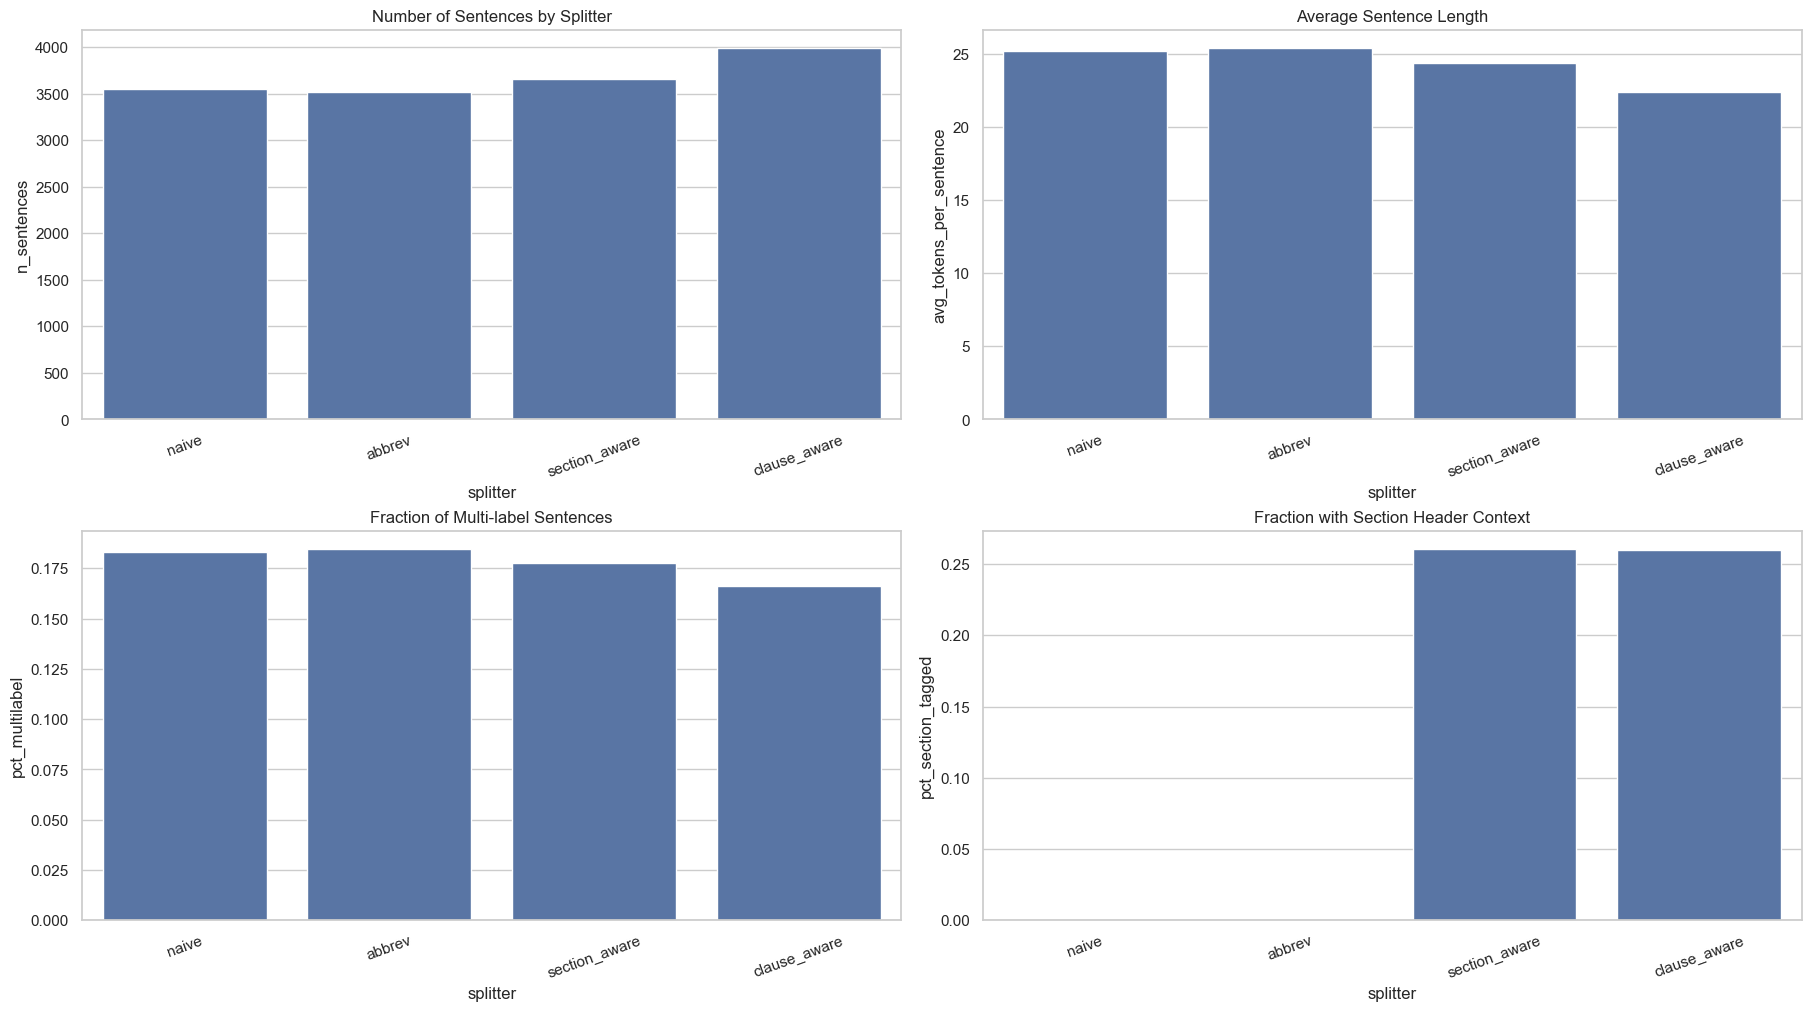

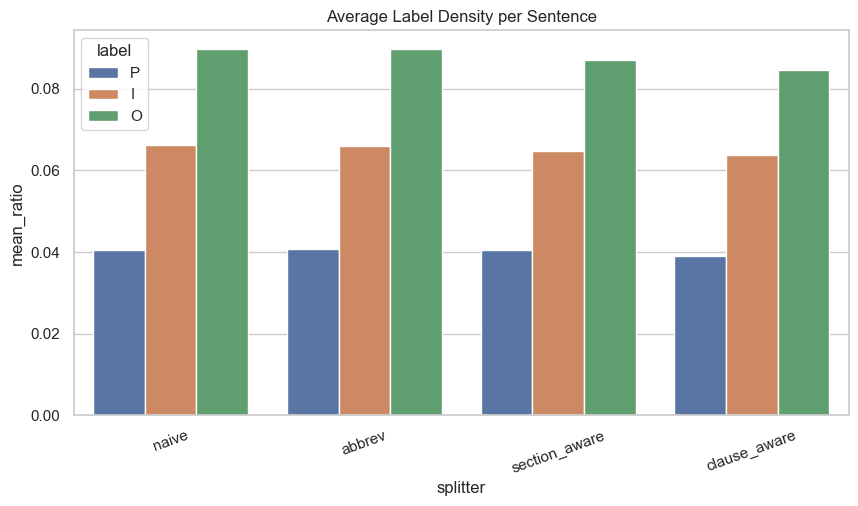

In [7]:
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

summary_rows = []
for name, df in sentence_tables.items():
    summary_rows.append({
        "splitter": name,
        "n_sentences": len(df),
        "avg_tokens_per_sentence": df["n_tokens"].mean(),
        "median_tokens_per_sentence": df["n_tokens"].median(),
        "pct_none": (df["schema_combo"] == "None").mean(),
        "pct_multilabel": (df["active_n_labels"] >= 2).mean(),
        "pct_section_tagged": df["section_hint"].ne("unspecified").mean(),
        "mean_P_ratio": df["P_ratio"].mean(),
        "mean_I_ratio": df["I_ratio"].mean(),
        "mean_O_ratio": df["O_ratio"].mean(),
    })

split_summary = pd.DataFrame(summary_rows)
display(split_summary.round(4))

fig, axes = plt.subplots(2, 2, figsize=(18, 10), constrained_layout=True)

sns.barplot(data=split_summary, x="splitter", y="n_sentences", ax=axes[0, 0])
axes[0, 0].set_title("Number of Sentences by Splitter")
axes[0, 0].tick_params(axis="x", rotation=20)

sns.barplot(data=split_summary, x="splitter", y="avg_tokens_per_sentence", ax=axes[0, 1])
axes[0, 1].set_title("Average Sentence Length")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.barplot(data=split_summary, x="splitter", y="pct_multilabel", ax=axes[1, 0])
axes[1, 0].set_title("Fraction of Multi-label Sentences")
axes[1, 0].tick_params(axis="x", rotation=20)

sns.barplot(data=split_summary, x="splitter", y="pct_section_tagged", ax=axes[1, 1])
axes[1, 1].set_title("Fraction with Section Header Context")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.show()

ratio_plot = split_summary.melt(
    id_vars="splitter",
    value_vars=["mean_P_ratio", "mean_I_ratio", "mean_O_ratio"],
    var_name="label",
    value_name="mean_ratio",
)
ratio_plot["label"] = ratio_plot["label"].str.replace("mean_", "").str.replace("_ratio", "")

plt.figure(figsize=(10, 5))
sns.barplot(data=ratio_plot, x="splitter", y="mean_ratio", hue="label")
plt.title("Average Label Density per Sentence")
plt.xticks(rotation=20)
plt.show()


## Embeddings, Clustering, and Evaluation

Once sentence-level units have been created, they are converted into vector representations using several embedding methods, including **TF-IDF + SVD**, **PubMedBERT**, and **Sentence-BERT**. Clustering is then performed with both **k-means** and **hierarchical agglomerative clustering (HAC)** so that we can compare how lexical and contextual representations behave under different unsupervised methods.

Because the task is naturally multi-label, evaluation is based on a set of report-friendly metrics rather than simple single-label accuracy. These include **micro-F1**, **macro-F1**, **per-label F1**, **coverage**, **dominant-label NMI**, and cluster-level label prevalence. Together, these metrics show both how coherent the clusters are and how well they align with the gold P/I/O schema fields.


In [8]:
from functools import lru_cache

import torch
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import (
    f1_score,
    normalized_mutual_info_score,
    precision_score,
    recall_score,
    silhouette_score,
)
from sklearn.metrics.cluster import contingency_matrix
from sklearn.preprocessing import Normalizer
from transformers import AutoModel, AutoTokenizer


EMBEDDING_SPECS = {
    "tfidf_svd": {
        "kind": "tfidf",
        "text_column": "sentence",
    },
    "pubmedbert": {
        "kind": "transformer",
        "model_name": "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract",
        "text_column": "context_with_section",
    },
    "sbert": {
        "kind": "transformer",
        "model_name": "sentence-transformers/all-MiniLM-L6-v2",
        "text_column": "context_sentence",
    },
}


def generate_tfidf_embeddings(texts):
    vectorizer = TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
    )
    tfidf = vectorizer.fit_transform(texts)
    max_rank = min(tfidf.shape[0] - 1, tfidf.shape[1] - 1)
    n_components = max(2, min(256, max_rank))
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    emb = svd.fit_transform(tfidf)
    emb = Normalizer(copy=False).fit_transform(emb)
    return emb


@lru_cache(maxsize=4)
def load_transformer_backbone(model_name: str, local_files_only: bool = False):
    tokenizer = AutoTokenizer.from_pretrained(model_name, local_files_only=local_files_only)
    model = AutoModel.from_pretrained(model_name, local_files_only=local_files_only)
    model.eval()
    return tokenizer, model


def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    masked = last_hidden_state * mask
    summed = masked.sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1e-9)
    return summed / denom


def generate_transformer_embeddings(texts, model_name, batch_size=16, max_length=256, local_files_only=False):
    tokenizer, model = load_transformer_backbone(model_name, local_files_only=local_files_only)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    all_embeddings = []
    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            batch = texts[start:start + batch_size]
            encoded = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt",
            )
            encoded = {k: v.to(device) for k, v in encoded.items()}
            outputs = model(**encoded)
            pooled = mean_pool(outputs.last_hidden_state, encoded["attention_mask"])
            pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
            all_embeddings.append(pooled.cpu().numpy())

    return np.vstack(all_embeddings)


def generate_sentence_embeddings(df, embedding_name="tfidf_svd", local_files_only=False):
    spec = EMBEDDING_SPECS[embedding_name]
    texts = df[spec["text_column"]].tolist()

    if spec["kind"] == "tfidf":
        return generate_tfidf_embeddings(texts)

    try:
        return generate_transformer_embeddings(
            texts,
            model_name=spec["model_name"],
            local_files_only=local_files_only,
        )
    except Exception as exc:
        warnings.warn(
            f"Could not load embedding backend '{embedding_name}' ({spec['model_name']}): {exc}"
        )
        return None


def run_hac(embeddings, n_clusters=4):
    row_norms = np.linalg.norm(embeddings, axis=1)
    has_zero_vector = np.any(row_norms == 0)

    metric = "euclidean" if has_zero_vector else "cosine"
    linkage = "ward" if metric == "euclidean" else "average"

    try:
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            metric=metric,
            linkage=linkage,
        )
    except TypeError:
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            affinity=metric,
            linkage=linkage,
        )

    return model.fit_predict(embeddings)



def run_kmeans(embeddings, n_clusters=4):
    model = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
    return model.fit_predict(embeddings)


LABEL_COLUMNS = ["has_P", "has_I", "has_O"]


def cluster_purity(y_true, y_pred):
    contingency = contingency_matrix(y_true, y_pred)
    return contingency.max(axis=0).sum() / contingency.sum()


def derive_cluster_multilabel_predictions(df, cluster_labels, threshold=0.35):
    eval_df = df.copy().reset_index(drop=True)
    eval_df["cluster"] = cluster_labels

    cluster_profiles = eval_df.groupby("cluster")[LABEL_COLUMNS].mean()
    cluster_predictions = (cluster_profiles >= threshold).astype(int)

    for cluster_id in cluster_predictions.index:
        if cluster_predictions.loc[cluster_id].sum() == 0 and cluster_profiles.loc[cluster_id].sum() > 0:
            best_col = cluster_profiles.loc[cluster_id].idxmax()
            cluster_predictions.loc[cluster_id, best_col] = 1

    pred = cluster_predictions.loc[eval_df["cluster"]].reset_index(drop=True)
    pred.columns = [col.replace("has_", "pred_") for col in pred.columns]
    return eval_df, cluster_profiles, pred


def evaluate_multilabel_clustering(df, cluster_labels, embeddings, threshold=0.35):
    eval_df, cluster_profiles, pred = derive_cluster_multilabel_predictions(df, cluster_labels, threshold=threshold)
    y_true = eval_df[LABEL_COLUMNS].to_numpy()
    y_pred = pred.to_numpy()

    metrics = {
        "coverage": float((y_pred.sum(axis=1) > 0).mean()),
        "micro_precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "micro_recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

    for label in ["P", "I", "O"]:
        metrics[f"{label}_f1"] = f1_score(eval_df[f"has_{label}"], pred[f"pred_{label}"], zero_division=0)

    single_label_df = eval_df[(eval_df["active_n_labels"] == 1) & (eval_df["dominant_label"].isin(["P", "I", "O"]))]
    if len(single_label_df) > 0:
        metrics["dominant_nmi"] = normalized_mutual_info_score(
            single_label_df["dominant_label"],
            single_label_df["cluster"],
        )
        metrics["dominant_purity"] = cluster_purity(
            single_label_df["dominant_label"],
            single_label_df["cluster"],
        )
    else:
        metrics["dominant_nmi"] = np.nan
        metrics["dominant_purity"] = np.nan

    if len(np.unique(cluster_labels)) > 1 and len(eval_df) > len(np.unique(cluster_labels)):
        metrics["silhouette"] = silhouette_score(embeddings, cluster_labels, metric="cosine")
    else:
        metrics["silhouette"] = np.nan

    return metrics, eval_df, cluster_profiles, pred


In [9]:
def project_2d(embeddings):
    pca_components = min(50, embeddings.shape[1], embeddings.shape[0] - 1)
    pca_init = PCA(n_components=max(2, pca_components), random_state=42)
    reduced = pca_init.fit_transform(embeddings)
    perplexity = min(30, max(5, len(embeddings) // 100))
    coords = TSNE(
        n_components=2,
        init="pca",
        learning_rate="auto",
        perplexity=perplexity,
        random_state=42,
    ).fit_transform(reduced)
    return coords


def compare_clustering_variants(
    splitter_names=None,
    embedding_names=None,
    n_clusters=5,
    local_files_only=False,
    threshold=0.35,
):
    splitter_names = splitter_names or list(sentence_tables.keys())
    embedding_names = embedding_names or list(EMBEDDING_SPECS.keys())
    rows = []

    for splitter_name in splitter_names:
        df = sentence_tables[splitter_name].copy()
        df = df[df["schema_combo"] != "None"].reset_index(drop=True)

        for embedding_name in embedding_names:
            embeddings = generate_sentence_embeddings(df, embedding_name=embedding_name, local_files_only=local_files_only)
            if embeddings is None:
                continue

            for algorithm_name, clusterer in {"hac": run_hac, "kmeans": run_kmeans}.items():
                cluster_labels = clusterer(embeddings, n_clusters=n_clusters)
                metrics, _, _, _ = evaluate_multilabel_clustering(
                    df,
                    cluster_labels,
                    embeddings,
                    threshold=threshold,
                )
                rows.append({
                    "splitter": splitter_name,
                    "embedding": embedding_name,
                    "algorithm": algorithm_name,
                    **metrics,
                })

    return pd.DataFrame(rows)


def build_report_summary(comparison_df):
    if comparison_df.empty:
        return comparison_df

    report_df = comparison_df.copy()
    report_df["setting"] = (
        report_df["splitter"] + " | " + report_df["embedding"] + " | " + report_df["algorithm"]
    )
    report_df = report_df.sort_values(
        ["micro_f1", "macro_f1", "dominant_nmi"],
        ascending=False,
    ).reset_index(drop=True)

    columns = [
        "setting", "micro_f1", "macro_f1", "P_f1", "I_f1", "O_f1",
        "coverage", "dominant_nmi", "silhouette"
    ]
    return report_df[columns].round(4)


def plot_report_figures(report_df):
    if report_df.empty:
        return

    plot_df = report_df.copy()
    plot_df[["splitter", "embedding", "algorithm"]] = plot_df["setting"].str.split(" | ", expand=True, regex=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    sns.barplot(
        data=plot_df,
        x="splitter",
        y="micro_f1",
        hue="embedding",
        ax=axes[0],
    )
    axes[0].set_title("Micro-F1 by splitter and embedding")
    axes[0].tick_params(axis="x", rotation=20)

    sns.barplot(
        data=plot_df,
        x="splitter",
        y="dominant_nmi",
        hue="embedding",
        ax=axes[1],
    )
    axes[1].set_title("Dominant-label NMI by splitter and embedding")
    axes[1].tick_params(axis="x", rotation=20)

    plt.show()


def plot_splitter_space(
    splitter_name,
    embedding_name="tfidf_svd",
    algorithm_name="kmeans",
    n_clusters=5,
    sample_size=1200,
    local_files_only=False,
    threshold=0.35,
):
    df = sentence_tables[splitter_name].copy()
    df = df[df["schema_combo"] != "None"].copy()

    if len(df) > sample_size:
        df = df.sample(sample_size, random_state=42).copy()

    embeddings = generate_sentence_embeddings(df, embedding_name=embedding_name, local_files_only=local_files_only)
    if embeddings is None:
        print(f"Skipping {embedding_name} because the model is not available.")
        return None

    clusterer = {"hac": run_hac, "kmeans": run_kmeans}[algorithm_name]
    cluster_labels = clusterer(embeddings, n_clusters=n_clusters)
    metrics, eval_df, cluster_profiles, _ = evaluate_multilabel_clustering(
        df,
        cluster_labels,
        embeddings,
        threshold=threshold,
    )

    coords = project_2d(embeddings)
    eval_df = eval_df.copy()
    eval_df["x"] = coords[:, 0]
    eval_df["y"] = coords[:, 1]
    eval_df["cluster"] = cluster_labels
    eval_df["dominant_or_combo"] = np.where(
        eval_df["active_n_labels"] == 1,
        eval_df["dominant_label"],
        eval_df["schema_combo"],
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

    sns.scatterplot(
        data=eval_df,
        x="x",
        y="y",
        hue="cluster",
        palette="tab10",
        s=28,
        alpha=0.8,
        ax=axes[0],
        legend="full",
    )
    axes[0].set_title(f"Clusters: {splitter_name} | {embedding_name} | {algorithm_name}")

    cluster_heatmap = cluster_profiles.copy()
    cluster_heatmap.columns = [col.replace("has_", "") for col in cluster_heatmap.columns]
    sns.heatmap(cluster_heatmap, annot=True, fmt=".2f", cmap="Blues", ax=axes[1])
    axes[1].set_title(
        f"Cluster label prevalence\nMicro-F1={metrics['micro_f1']:.3f}, NMI={metrics['dominant_nmi']:.3f}"
    )
    axes[1].set_xlabel("Gold label")
    axes[1].set_ylabel("Cluster")

    plt.show()
    return pd.DataFrame([metrics]).round(4)


## Results Overview

The final section condenses the clustering experiments into a compact comparison table and a small set of summary plots. Rather than displaying every possible combination in detail, the notebook highlights the strongest configurations and then visualises one representative clustering result in more depth.

This keeps the output suitable for a report: the table provides an overall ranking of settings, the bar charts show the main trends across splitters and embeddings, and the final cluster plot illustrates what the best-performing configuration looks like in practice.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,setting,micro_f1,macro_f1,P_f1,I_f1,O_f1,coverage,dominant_nmi,silhouette
0,abbrev | tfidf_svd | kmeans,0.6906,0.6734,0.5595,0.6919,0.7689,1.0,0.1440,0.0222
1,naive | tfidf_svd | kmeans,0.6659,0.6218,0.4646,0.6611,0.7397,1.0,0.0768,0.0195
2,abbrev | pubmedbert | kmeans,0.6546,0.6211,0.4854,0.6588,0.7191,1.0,0.0438,0.0711
3,section_aware | pubmedbert | kmeans,0.6540,0.6194,0.4757,0.6652,0.7173,1.0,0.0523,0.0722
4,clause_aware | tfidf_svd | kmeans,0.6518,0.5674,0.3078,0.6494,0.7449,1.0,0.0870,0.0204
5,section_aware | tfidf_svd | kmeans,0.6486,0.5470,0.2551,0.6587,0.7274,1.0,0.0584,0.0200
6,naive | pubmedbert | kmeans,0.6395,0.4633,0.0000,0.6711,0.7187,1.0,0.0519,0.0754
7,clause_aware | pubmedbert | kmeans,0.6373,0.5713,0.3567,0.6425,0.7148,1.0,0.0303,0.0774
8,section_aware | sbert | kmeans,0.6318,0.5372,0.2520,0.6424,0.7173,1.0,0.0083,0.0715
9,abbrev | pubmedbert | hac,0.6307,0.4668,0.0356,0.6435,0.7212,1.0,0.0105,0.1980


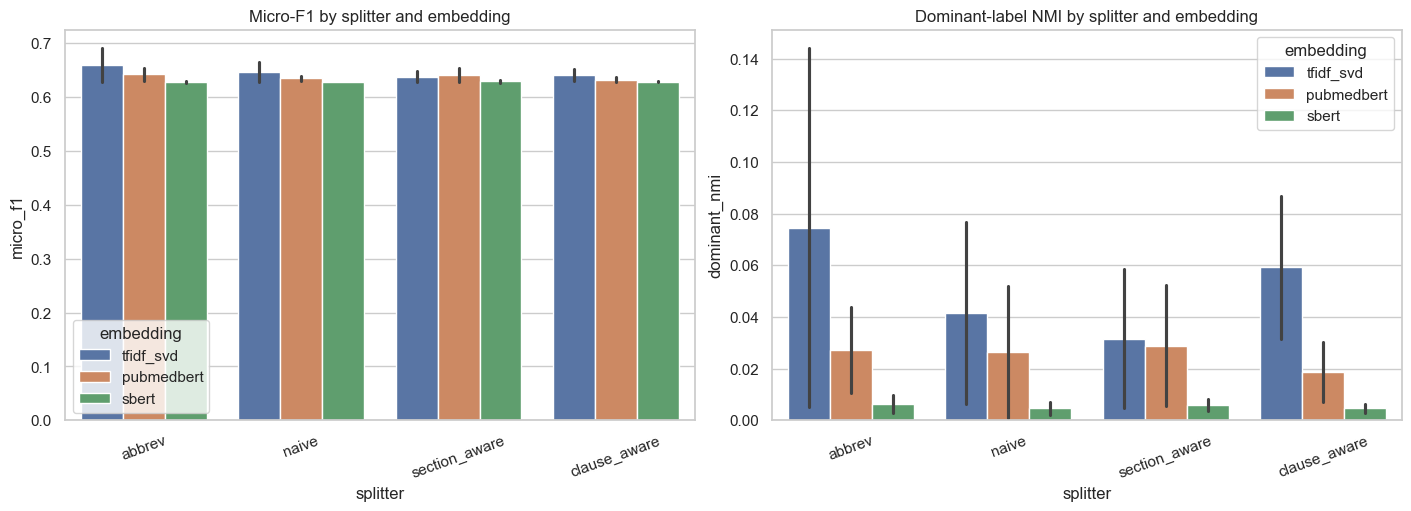

Best setting: abbrev | tfidf_svd | kmeans


a:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


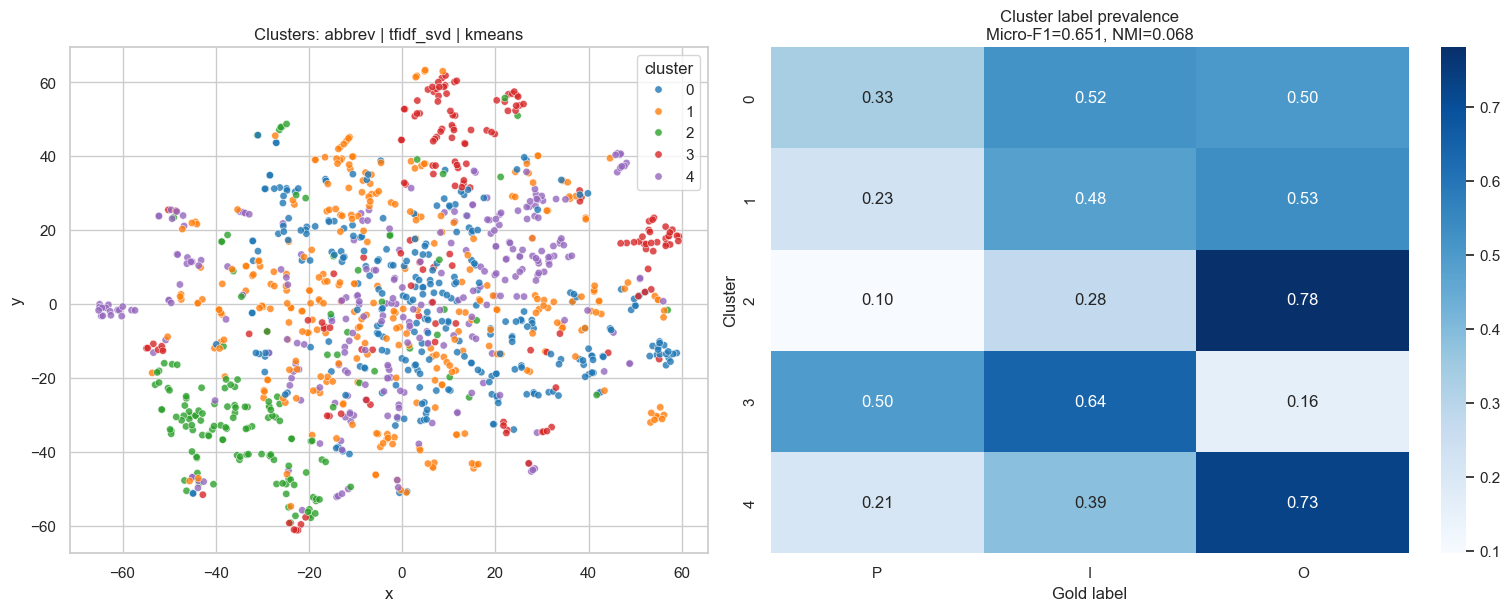

In [10]:
comparison_df = compare_clustering_variants(
    splitter_names=list(sentence_tables.keys()),
    embedding_names=["tfidf_svd", "pubmedbert", "sbert"],
    n_clusters=5,
    local_files_only=True,
)

report_df = build_report_summary(comparison_df)
display(report_df)
plot_report_figures(report_df)

if not comparison_df.empty:
    best_row = comparison_df.sort_values(
        ["micro_f1", "macro_f1", "dominant_nmi"],
        ascending=False,
    ).iloc[0]

    print(
        "Best setting:",
        f"{best_row['splitter']} | {best_row['embedding']} | {best_row['algorithm']}"
    )

    plot_splitter_space(
        best_row["splitter"],
        embedding_name=best_row["embedding"],
        algorithm_name=best_row["algorithm"],
        n_clusters=5,
        local_files_only=True,
    )
